# Behavioral Market Sentiment Analysis on Hyperliquid Trader Data
## Quantitative Research & Behavioral Trading Analysis

Imports & Configuration

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import os

os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/plots', exist_ok=True)

# Styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

print("All libraries loaded successfully")


All libraries loaded successfully


Load & Inspect Data

In [53]:
# Load datasets
fg = pd.read_csv('data/fear_greed_index.csv')
hd = pd.read_csv('data/historical_data.csv')

print("=" * 50)
print("FEAR & GREED INDEX")
print("=" * 50)
print(f"Shape: {fg.shape}")
print(f"Columns: {list(fg.columns)}")
print(fg.head())
print()

print("=" * 50)
print("HISTORICAL TRADER DATA")
print("=" * 50)
print(f"Shape: {hd.shape}")
print(f"Columns: {list(hd.columns)}")
print(hd.head())

FEAR & GREED INDEX
Shape: (2644, 4)
Columns: ['timestamp', 'value', 'classification', 'date']
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

HISTORICAL TRADER DATA
Shape: (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.98

In [54]:
# Data info & missing values
print("FEAR & GREED — Dtypes & Nulls")
print(fg.info())
print("\nMissing values:\n", fg.isnull().sum())

print("\nHISTORICAL DATA — Dtypes & Nulls")
print(hd.info())
print("\nMissing values:\n", hd.isnull().sum())

FEAR & GREED — Dtypes & Nulls
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
None

Missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

HISTORICAL DATA — Dtypes & Nulls
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 no

In [55]:
# Statistical summary
print("FEAR & GREED — Stats")
print(fg.describe())

print("\nHISTORICAL DATA — Stats")
print(hd[['Execution Price', 'Size USD', 'Closed PnL', 'Fee']].describe())

print(f"\nUnique traders: {hd['Account'].nunique()}")
print(f"Unique coins:   {hd['Coin'].nunique()}")
print(f"Sides: {hd['Side'].unique()}")
print(f"Sentiment categories: {fg['classification'].unique()}")

FEAR & GREED — Stats
            timestamp     value
count       2644.0000 2644.0000
mean  1631898885.0227   46.9811
std     65979674.3222   21.8277
min   1517463000.0000    5.0000
25%   1574811000.0000   28.0000
50%   1631899800.0000   46.0000
75%   1688988600.0000   66.0000
max   1746163800.0000   95.0000

HISTORICAL DATA — Stats
       Execution Price     Size USD   Closed PnL         Fee
count      211224.0000  211224.0000  211224.0000 211224.0000
mean        11414.7233    5639.4512      48.7490      1.1640
std         29447.6549   36575.1385     919.1648      6.7589
min             0.0000       0.0000 -117990.1041     -1.1757
25%             4.8547     193.7900       0.0000      0.0161
50%            18.2800     597.0450       0.0000      0.0896
75%           101.5800    2058.9600       5.7928      0.3938
max        109004.0000 3921430.7200  135329.0901    837.4716

Unique traders: 32
Unique coins:   246
Sides: <StringArray>
['BUY', 'SELL']
Length: 2, dtype: str
Sentiment categori

Data Cleaning & Feature Engineering

In [56]:
# Clean Fear & Greed Index
fg['date'] = pd.to_datetime(fg['date'])
fg = fg.sort_values('date').reset_index(drop=True)

# Ordered categorical for correct sorting
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
fg['classification'] = pd.Categorical(fg['classification'],
                                       categories=sentiment_order,
                                       ordered=True)

# Numeric sentiment score (1=Extreme Fear, 5=Extreme Greed)
sentiment_map = {s: i+1 for i, s in enumerate(sentiment_order)}
fg['sentiment_score'] = fg['classification'].map(sentiment_map)

print(fg.head())
print(fg.dtypes)

    timestamp  value classification       date sentiment_score
0  1517463000     30           Fear 2018-02-01               2
1  1517549400     15   Extreme Fear 2018-02-02               1
2  1517635800     40           Fear 2018-02-03               2
3  1517722200     24   Extreme Fear 2018-02-04               1
4  1517808600     11   Extreme Fear 2018-02-05               1
timestamp                   int64
value                       int64
classification           category
date               datetime64[us]
sentiment_score          category
dtype: object


In [57]:
# Clean Historical Trader Data
# Parse timestamp (format: DD-MM-YYYY HH:MM)
hd['datetime'] = pd.to_datetime(hd['Timestamp IST'], format='%d-%m-%Y %H:%M')
hd['date'] = hd['datetime'].dt.date
hd['date'] = pd.to_datetime(hd['date'])
hd['month'] = hd['datetime'].dt.to_period('M')
hd['hour'] = hd['datetime'].dt.hour
hd['day_of_week'] = hd['datetime'].dt.day_name()
hd['week'] = hd['datetime'].dt.isocalendar().week

# Feature: Net PnL after fee
hd['net_pnl'] = hd['Closed PnL'] - hd['Fee']

# Feature: Is trade profitable?
hd['is_win'] = hd['Closed PnL'] > 0

# Feature: Trade closed? (PnL != 0)
hd['is_closed'] = hd['Closed PnL'] != 0

# Feature: Shorten account address for readability
hd['trader'] = hd['Account'].str[:10] + '...'

print(hd[['datetime', 'date', 'month', 'hour', 'Closed PnL', 'net_pnl', 'is_win', 'is_closed']].head(10))
print(hd.shape)

             datetime       date    month  hour  Closed PnL  net_pnl  is_win  \
0 2024-12-02 22:50:00 2024-12-02  2024-12    22      0.0000  -0.3454   False   
1 2024-12-02 22:50:00 2024-12-02  2024-12    22      0.0000  -0.0056   False   
2 2024-12-02 22:50:00 2024-12-02  2024-12    22      0.0000  -0.0504   False   
3 2024-12-02 22:50:00 2024-12-02  2024-12    22      0.0000  -0.0500   False   
4 2024-12-02 22:50:00 2024-12-02  2024-12    22      0.0000  -0.0031   False   
5 2024-12-02 22:50:00 2024-12-02  2024-12    22      0.0000  -0.0005   False   
6 2024-12-02 22:50:00 2024-12-02  2024-12    22      0.0000  -0.0504   False   
7 2024-12-02 22:50:00 2024-12-02  2024-12    22      0.0000  -0.0119   False   
8 2024-12-02 22:50:00 2024-12-02  2024-12    22      0.0000  -0.0161   False   
9 2024-12-02 22:50:00 2024-12-02  2024-12    22      0.0000  -0.0044   False   

   is_closed  
0      False  
1      False  
2      False  
3      False  
4      False  
5      False  
6      False  

In [58]:
# Merge datasets on date
merged = hd.merge(
    fg[['date', 'classification', 'value', 'sentiment_score']],
    on='date',
    how='left'
)

print(f"Merged shape: {merged.shape}")
print(f"Rows with sentiment matched: {merged['classification'].notna().sum()}")
print(f"Unmatched rows: {merged['classification'].isna().sum()}")
print(merged[['datetime', 'date', 'Closed PnL', 'classification', 'value']].head(10))

Merged shape: (211224, 29)
Rows with sentiment matched: 211218
Unmatched rows: 6
             datetime       date  Closed PnL classification   value
0 2024-12-02 22:50:00 2024-12-02      0.0000  Extreme Greed 80.0000
1 2024-12-02 22:50:00 2024-12-02      0.0000  Extreme Greed 80.0000
2 2024-12-02 22:50:00 2024-12-02      0.0000  Extreme Greed 80.0000
3 2024-12-02 22:50:00 2024-12-02      0.0000  Extreme Greed 80.0000
4 2024-12-02 22:50:00 2024-12-02      0.0000  Extreme Greed 80.0000
5 2024-12-02 22:50:00 2024-12-02      0.0000  Extreme Greed 80.0000
6 2024-12-02 22:50:00 2024-12-02      0.0000  Extreme Greed 80.0000
7 2024-12-02 22:50:00 2024-12-02      0.0000  Extreme Greed 80.0000
8 2024-12-02 22:50:00 2024-12-02      0.0000  Extreme Greed 80.0000
9 2024-12-02 22:50:00 2024-12-02      0.0000  Extreme Greed 80.0000


In [59]:
# Filter only closed trades with sentiment info
closed = merged[(merged['is_closed']) & (merged['classification'].notna())].copy()
print(f"Closed trades with sentiment: {len(closed)}")
print(closed['classification'].value_counts())

Closed trades with sentiment: 104402
classification
Fear             29808
Greed            25176
Extreme Greed    20853
Neutral          18159
Extreme Fear     10406
Name: count, dtype: int64


Exploratory Data Analysis (EDA)

Fear & Greed Distribution Over Time

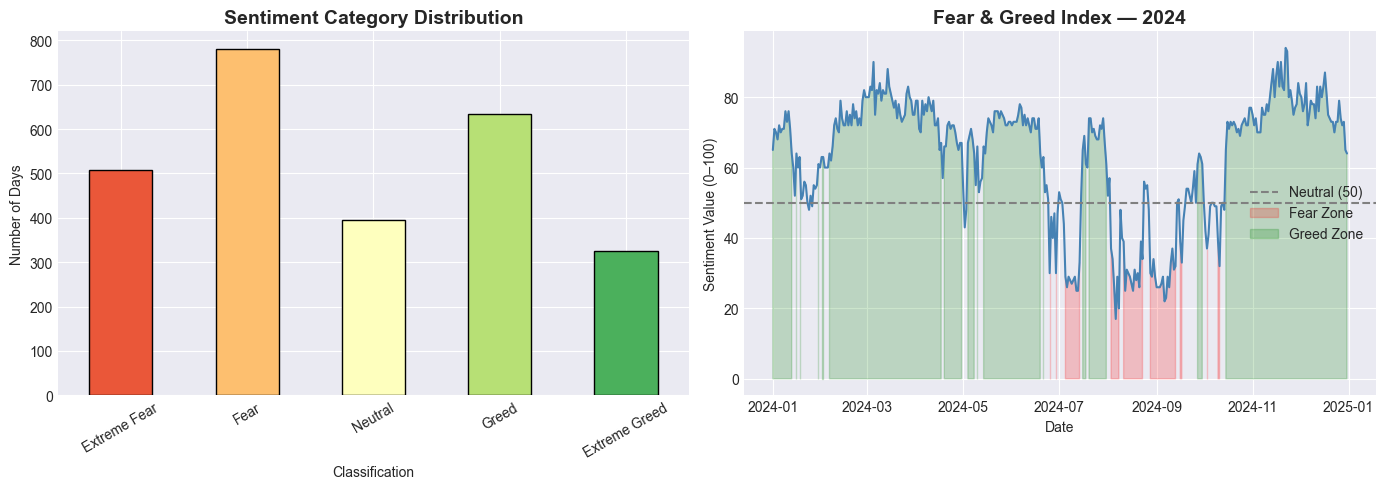

✅ Saved: plots/01_sentiment_overview.png


In [60]:
# Sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
fg['classification'].value_counts().reindex(sentiment_order).plot(
    kind='bar', ax=axes[0], color=sns.color_palette("RdYlGn", 5), edgecolor='black'
)
axes[0].set_title('Sentiment Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classification')
axes[0].set_ylabel('Number of Days')
axes[0].tick_params(axis='x', rotation=30)

# Sentiment value over time (2024 only)
fg_2024 = fg[fg['date'].dt.year == 2024]
axes[1].plot(fg_2024['date'], fg_2024['value'], color='steelblue', linewidth=1.5)
axes[1].axhline(50, color='gray', linestyle='--', label='Neutral (50)')
axes[1].fill_between(fg_2024['date'], 0, fg_2024['value'],
                     where=(fg_2024['value'] < 40), color='red', alpha=0.2, label='Fear Zone')
axes[1].fill_between(fg_2024['date'], 0, fg_2024['value'],
                     where=(fg_2024['value'] > 60), color='green', alpha=0.2, label='Greed Zone')
axes[1].set_title('Fear & Greed Index — 2024', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sentiment Value (0–100)')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/plots/01_sentiment_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/01_sentiment_overview.png")

Trade Volume by Sentiment

                trade_count  total_volume_usd  avg_trade_size
classification                                               
Extreme Fear          10406     56895537.7800       5467.5700
Fear                  29808    239690314.3900       8041.1400
Neutral               18159    100899481.7300       5556.4400
Greed                 25176    136924000.3300       5438.6700
Extreme Greed         20853     57962240.4200       2779.5600


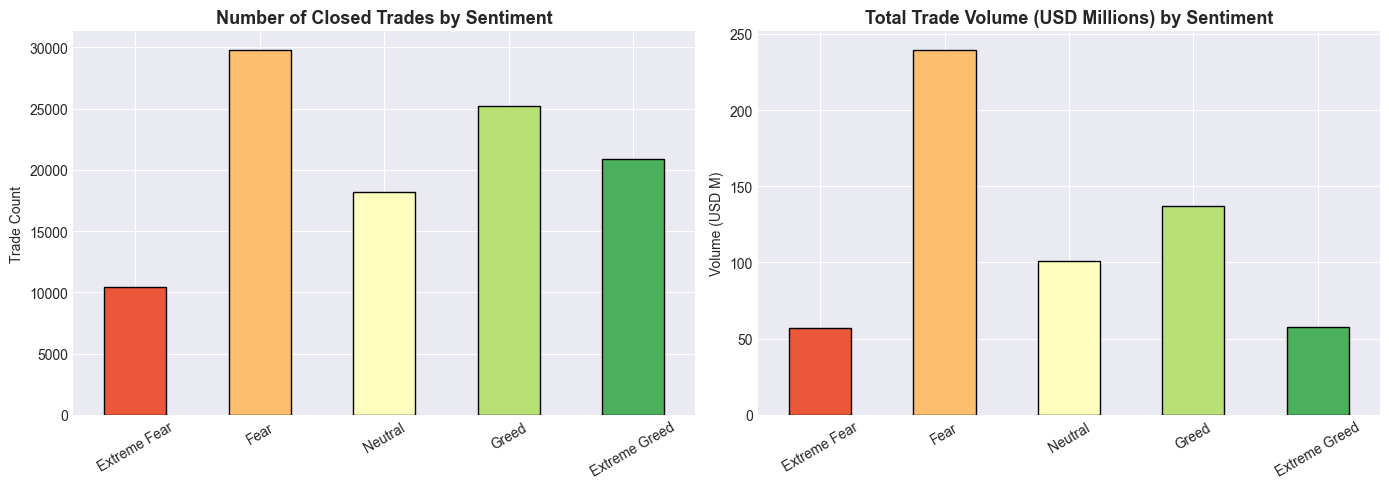

In [61]:
# Trade volume & USD volume by sentiment
vol_by_sentiment = closed.groupby('classification', observed=True).agg(
    trade_count=('Closed PnL', 'count'),
    total_volume_usd=('Size USD', 'sum'),
    avg_trade_size=('Size USD', 'mean')
).reindex(sentiment_order)

print(vol_by_sentiment.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("RdYlGn", 5)

vol_by_sentiment['trade_count'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Number of Closed Trades by Sentiment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Trade Count')
axes[0].tick_params(axis='x', rotation=30)

vol_by_sentiment['total_volume_usd'].div(1e6).plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Total Trade Volume (USD Millions) by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Volume (USD M)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/plots/02_volume_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

PnL Analysis by Sentiment

PnL by Sentiment:
                  total_pnl  avg_pnl  median_pnl  win_rate  trade_count  \
classification                                                            
Extreme Fear    739110.2485  71.0273      6.3880    0.7622        10406   
Fear           3357155.4416 112.6260      6.3505    0.8729        29808   
Neutral        1292920.6756  71.2000      4.5835    0.8239        18159   
Greed          2150129.2730  85.4039      4.9276    0.7689        25176   
Extreme Greed  2715171.3107 130.2053      8.5307    0.8917        20853   

                win_rate_pct  
classification                
Extreme Fear         76.2156  
Fear                 87.2886  
Neutral              82.3889  
Greed                76.8907  
Extreme Greed        89.1670  


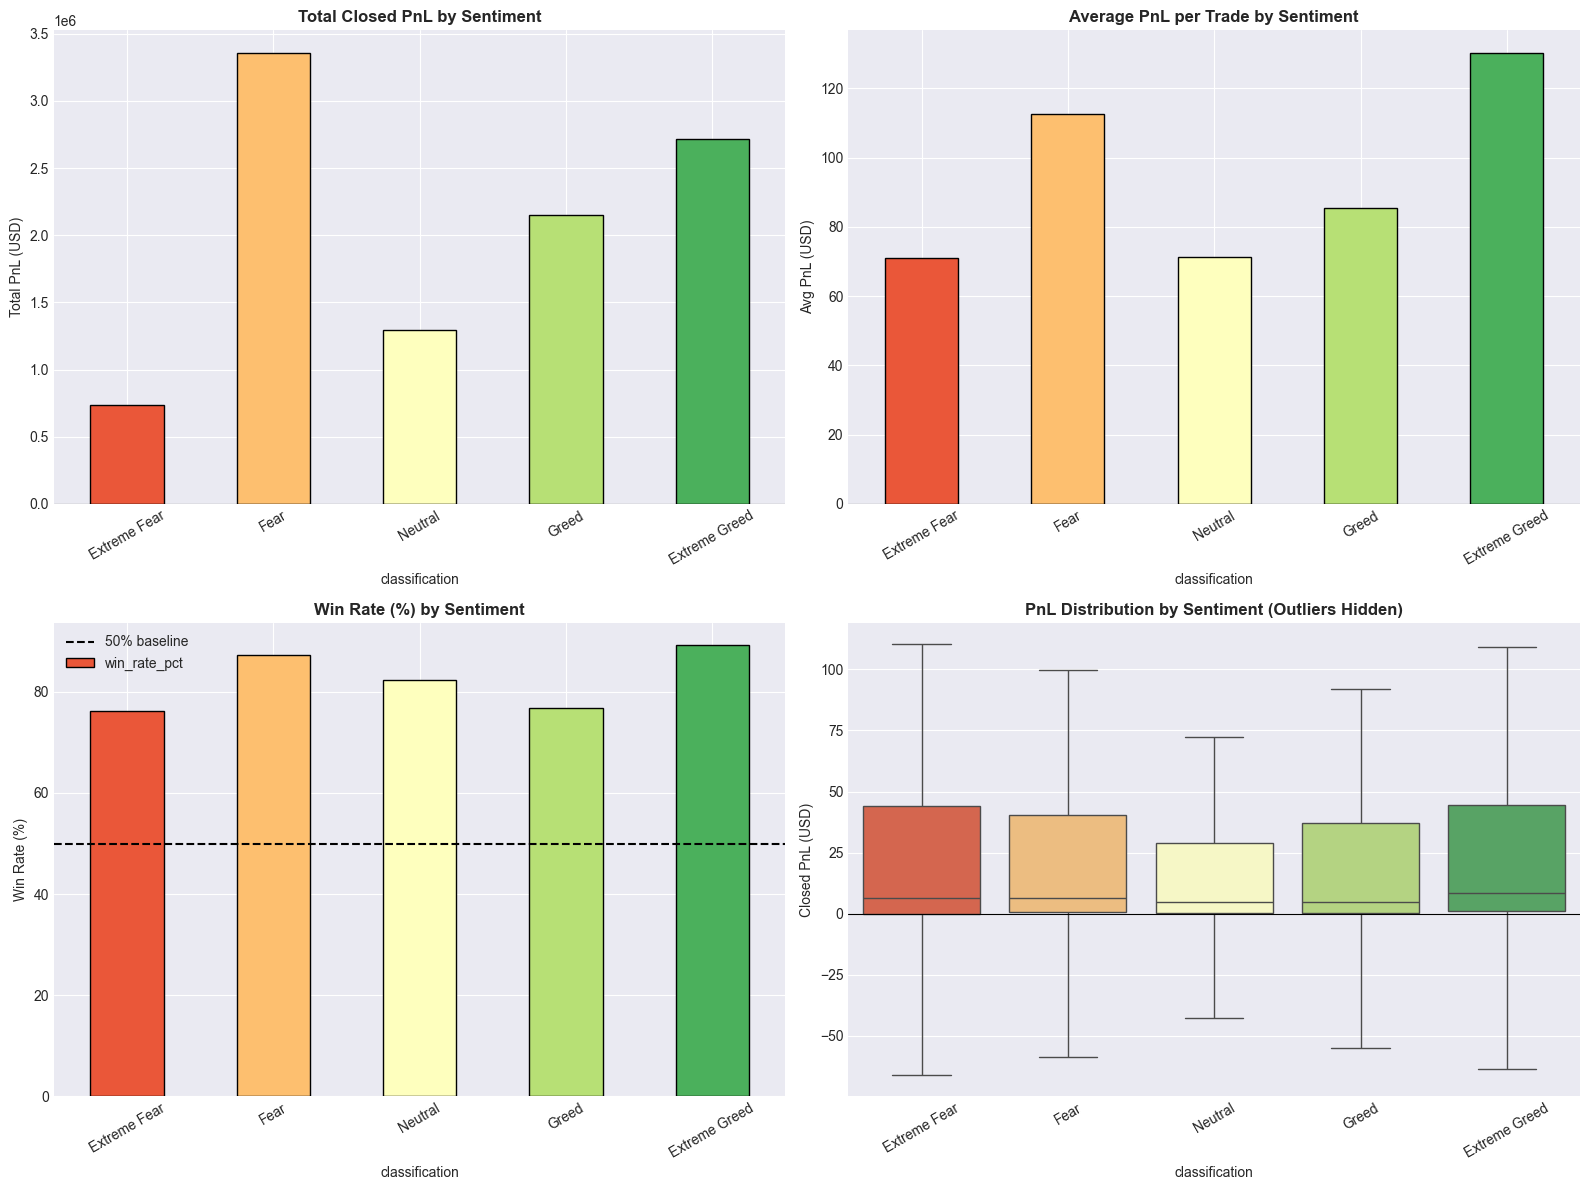

In [62]:
# PnL distributions by sentiment
pnl_by_sentiment = closed.groupby('classification', observed=True).agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    win_rate=('is_win', 'mean'),
    trade_count=('Closed PnL', 'count')
).reindex(sentiment_order)
pnl_by_sentiment['win_rate_pct'] = pnl_by_sentiment['win_rate'] * 100

print("PnL by Sentiment:")
print(pnl_by_sentiment.round(4))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = sns.color_palette("RdYlGn", 5)

# Total PnL
pnl_by_sentiment['total_pnl'].plot(kind='bar', ax=axes[0,0], color=colors, edgecolor='black')
axes[0,0].set_title('Total Closed PnL by Sentiment', fontweight='bold')
axes[0,0].set_ylabel('Total PnL (USD)')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].axhline(0, color='black', linewidth=0.8)

# Average PnL
pnl_by_sentiment['avg_pnl'].plot(kind='bar', ax=axes[0,1], color=colors, edgecolor='black')
axes[0,1].set_title('Average PnL per Trade by Sentiment', fontweight='bold')
axes[0,1].set_ylabel('Avg PnL (USD)')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].axhline(0, color='black', linewidth=0.8)

# Win rate
pnl_by_sentiment['win_rate_pct'].plot(kind='bar', ax=axes[1,0], color=colors, edgecolor='black')
axes[1,0].axhline(50, color='black', linestyle='--', label='50% baseline')
axes[1,0].set_title('Win Rate (%) by Sentiment', fontweight='bold')
axes[1,0].set_ylabel('Win Rate (%)')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].legend()

# Box plot PnL distribution
sns.boxplot(data=closed, x='classification', y='Closed PnL', order=sentiment_order,
            palette="RdYlGn", ax=axes[1,1], showfliers=False)
axes[1,1].set_title('PnL Distribution by Sentiment (Outliers Hidden)', fontweight='bold')
axes[1,1].set_ylabel('Closed PnL (USD)')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('outputs/plots/03_pnl_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

Trader-Level Performance Analysis

In [63]:
# Trader performance summary
trader_perf = closed.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    net_pnl=('net_pnl', 'sum'),
    total_trades=('Closed PnL', 'count'),
    win_rate=('is_win', 'mean'),
    avg_pnl_per_trade=('Closed PnL', 'mean'),
    total_volume_usd=('Size USD', 'sum'),
    total_fees=('Fee', 'sum'),
    avg_trade_size=('Size USD', 'mean')
).reset_index()

trader_perf['win_rate_pct'] = trader_perf['win_rate'] * 100
trader_perf['roi'] = trader_perf['total_pnl'] / trader_perf['total_volume_usd'] * 100
trader_perf = trader_perf.sort_values('total_pnl', ascending=False).reset_index(drop=True)

# Short label
trader_perf['trader_label'] = trader_perf['Account'].str[:10] + '...'

print("Top 10 Traders by Total PnL:")
print(trader_perf.head(10)[['trader_label', 'total_pnl', 'total_trades', 
                              'win_rate_pct', 'avg_pnl_per_trade', 'total_fees']].round(2).to_string())

Top 10 Traders by Total PnL:
    trader_label    total_pnl  total_trades  win_rate_pct  avg_pnl_per_trade  total_fees
0  0xb1231a4a... 2143382.6000          6279       79.1000           341.3600   7048.2300
1  0x083384f8... 1600229.8200          1732       79.2700           923.9200   3644.3400
2  0xbaaaf657...  940163.8100          9997       99.1200            94.0400   5415.2500
3  0x513b8629...  840422.5600          5482       89.5500           153.3100  37357.9500
4  0xbee1707d...  836080.5500         22551       76.3100            37.0800   8688.6400
5  0x4acb90e7...  677747.0500          2233       94.8500           303.5100   4456.5800
6  0x72743ae2...  429355.5700           737       74.6300           582.5700    617.5300
7  0x430f0984...  416541.8700           599      100.0000           695.4000    252.7200
8  0x75f7eeb8...  379095.4100          8660       92.6300            43.7800   1734.6600
9  0x72c6a462...  360539.5100           558       77.4200           646.1300    1

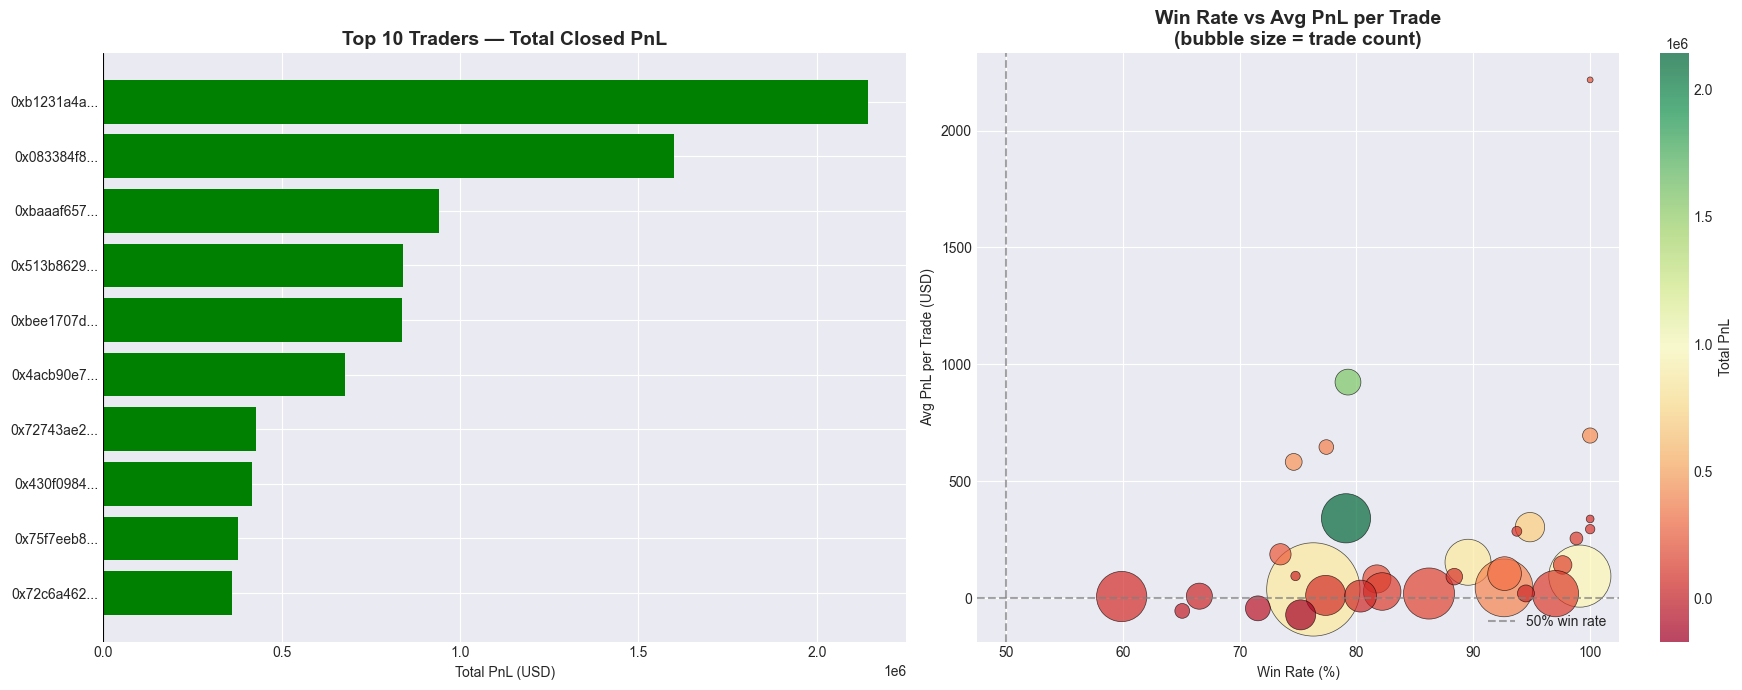

In [64]:
# Trader ranking chart
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
top10 = trader_perf.head(10)

# Total PnL bar
bars = axes[0].barh(top10['trader_label'][::-1], top10['total_pnl'][::-1],
                     color=['green' if v > 0 else 'red' for v in top10['total_pnl'][::-1]])
axes[0].set_title('Top 10 Traders — Total Closed PnL', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total PnL (USD)')
axes[0].axvline(0, color='black', linewidth=0.8)

# Win Rate vs Avg PnL scatter
scatter = axes[1].scatter(trader_perf['win_rate_pct'], trader_perf['avg_pnl_per_trade'],
                           s=trader_perf['total_trades']/5, c=trader_perf['total_pnl'],
                           cmap='RdYlGn', alpha=0.7, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, ax=axes[1], label='Total PnL')
axes[1].axvline(50, color='gray', linestyle='--', alpha=0.7, label='50% win rate')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Win Rate vs Avg PnL per Trade\n(bubble size = trade count)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Win Rate (%)')
axes[1].set_ylabel('Avg PnL per Trade (USD)')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/plots/04_trader_performance.png', dpi=150, bbox_inches='tight')
plt.show()

Sentiment vs Trader Behaviour Deep Dive

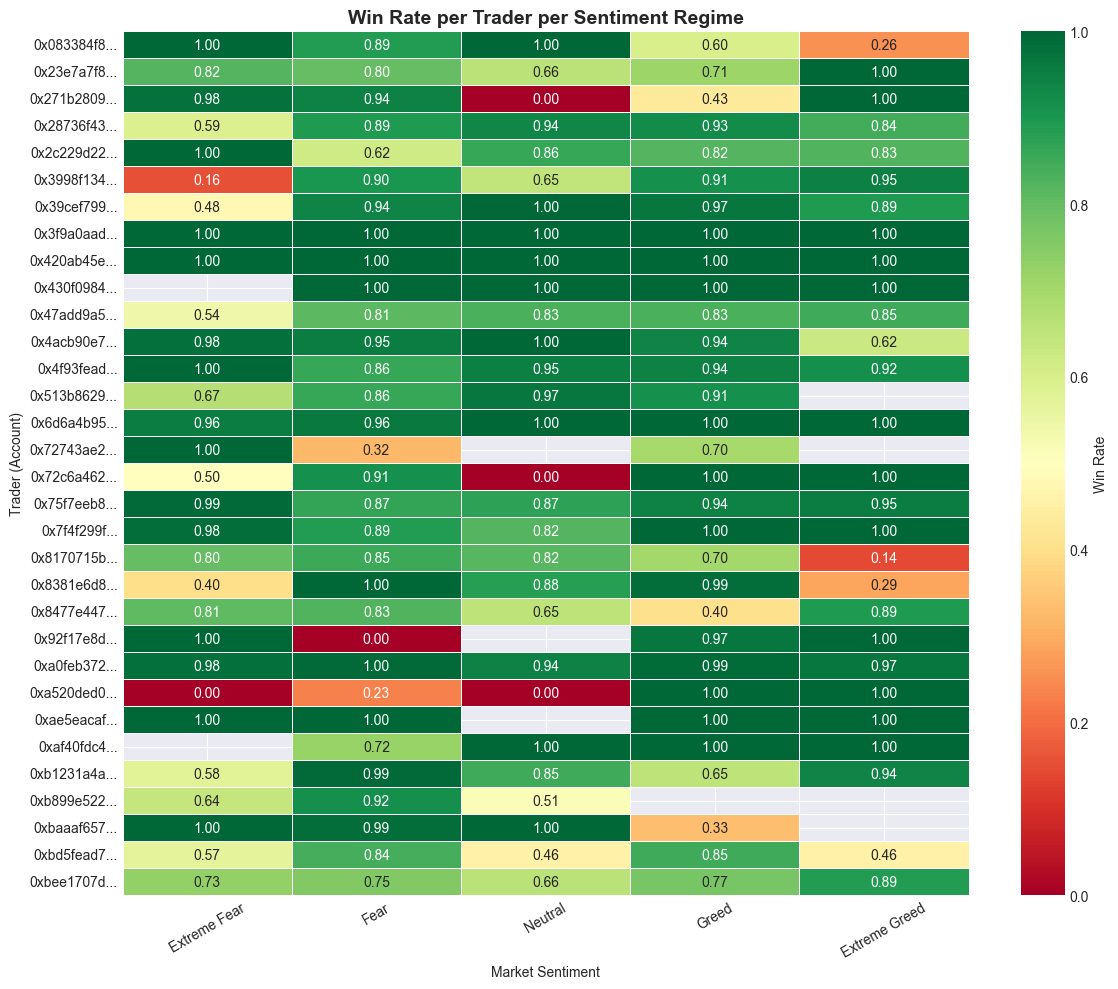

In [65]:
# Win rate per trader per sentiment
trader_sentiment = closed.groupby(['Account', 'classification'], observed=True).agg(
    trades=('Closed PnL', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean')
).reset_index()

# Pivot for heatmap
wr_pivot = trader_sentiment.pivot_table(
    index='Account', columns='classification', values='win_rate', observed=True
)[sentiment_order]

wr_pivot.index = [idx[:10] + '...' for idx in wr_pivot.index]

plt.figure(figsize=(12, 10))
sns.heatmap(wr_pivot, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Win Rate'})
plt.title('Win Rate per Trader per Sentiment Regime', fontsize=14, fontweight='bold')
plt.xlabel('Market Sentiment')
plt.ylabel('Trader (Account)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/plots//05_winrate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

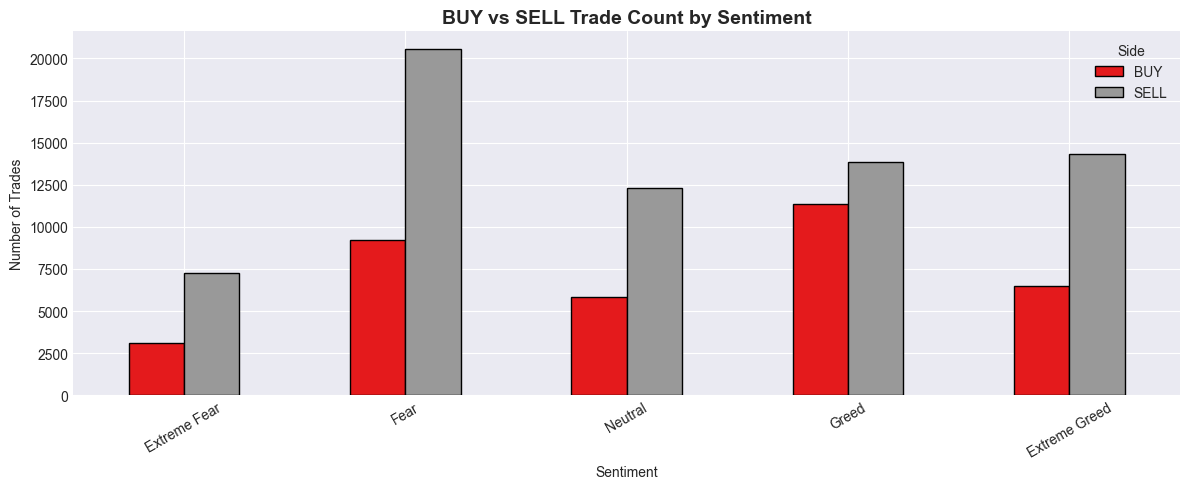

In [66]:
# Buy vs Sell behaviour by sentiment
side_sentiment = closed.groupby(['Side', 'classification'], observed=True).agg(
    count=('Closed PnL', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean')
).reset_index()

side_pivot = side_sentiment.pivot_table(
    index='Side', columns='classification', values='count', observed=True
)[sentiment_order]

ax = side_pivot.T.plot(kind='bar', figsize=(12, 5), colormap='Set1', edgecolor='black')
ax.set_title('BUY vs SELL Trade Count by Sentiment', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of Trades')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Side')
plt.tight_layout()
plt.savefig('outputs/plots/06_buy_sell_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

In [67]:
# Contrarian analysis — are traders more profitable trading AGAINST sentiment?
# BUY in Fear = contrarian bullish | SELL in Greed = contrarian bearish
def get_strategy(row):
    if row['Side'] == 'BUY' and row['classification'] in ['Extreme Fear', 'Fear']:
        return 'Contrarian Buy (Fear)'
    elif row['Side'] == 'SELL' and row['classification'] in ['Extreme Greed', 'Greed']:
        return 'Contrarian Sell (Greed)'
    elif row['Side'] == 'BUY' and row['classification'] in ['Extreme Greed', 'Greed']:
        return 'Momentum Buy (Greed)'
    elif row['Side'] == 'SELL' and row['classification'] in ['Extreme Fear', 'Fear']:
        return 'Momentum Sell (Fear)'
    else:
        return 'Neutral Market'

closed['strategy_type'] = closed.apply(get_strategy, axis=1)

strat_perf = closed.groupby('strategy_type').agg(
    count=('Closed PnL', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean')
).round(4)
strat_perf['win_rate_pct'] = strat_perf['win_rate'] * 100

print("Strategy Performance:")
print(strat_perf.sort_values('avg_pnl', ascending=False).to_string())

Strategy Performance:
                         count    total_pnl  avg_pnl  win_rate  win_rate_pct
strategy_type                                                               
Contrarian Buy (Fear)    12353 2308116.8808 186.8467    0.8230       82.3000
Contrarian Sell (Greed)  28186 4062493.2448 144.1316    0.8709       87.0900
Neutral Market           18159 1292920.6756  71.2000    0.8239       82.3900
Momentum Sell (Fear)     27861 1788148.8094  64.1811    0.8537       85.3700
Momentum Buy (Greed)     17843  802807.3388  44.9928    0.7512       75.1200


Temporal Patterns

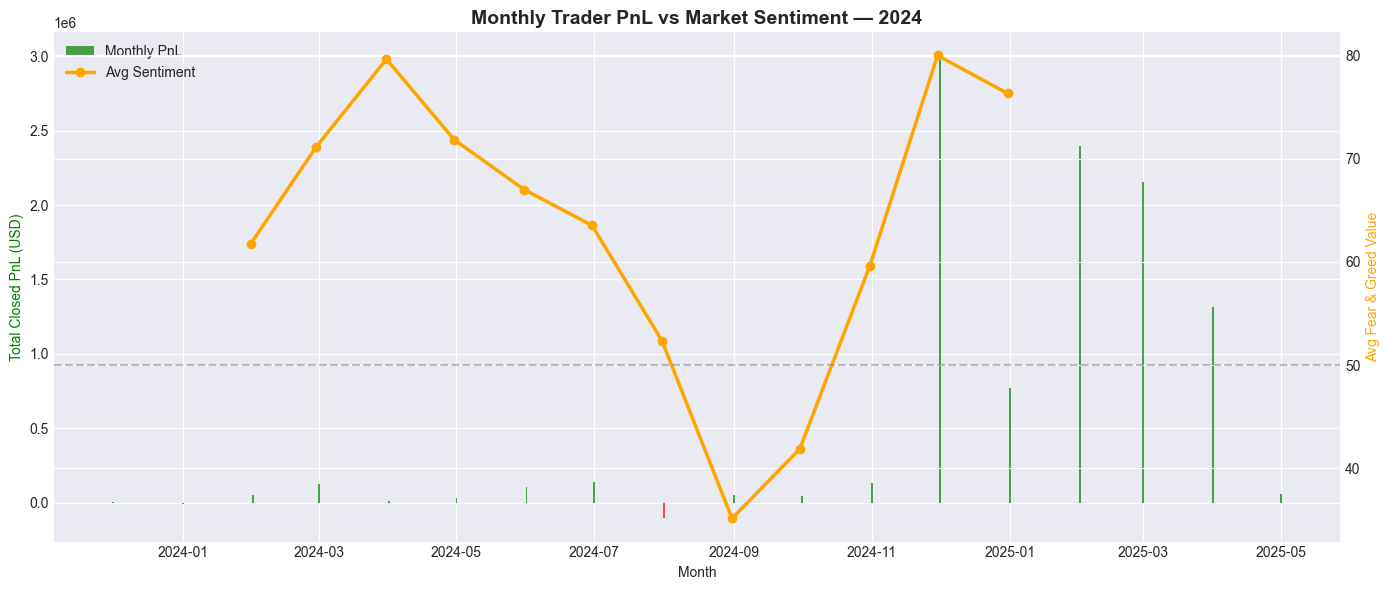

In [68]:
# Monthly PnL + Sentiment Trend
monthly_pnl = closed.groupby('month').agg(
    total_pnl=('Closed PnL', 'sum'),
    trades=('Closed PnL', 'count')
).reset_index()
monthly_pnl['month_dt'] = monthly_pnl['month'].dt.to_timestamp()

monthly_sentiment = fg[fg['date'].dt.year == 2024].set_index('date')['value'].resample('ME').mean().reset_index()
monthly_sentiment.columns = ['date', 'avg_sentiment']

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.bar(monthly_pnl['month_dt'], monthly_pnl['total_pnl'],
        color=['green' if x > 0 else 'red' for x in monthly_pnl['total_pnl']],
        alpha=0.7, label='Monthly PnL')
ax2.plot(monthly_sentiment['date'], monthly_sentiment['avg_sentiment'],
         color='orange', linewidth=2.5, marker='o', label='Avg Sentiment')
ax2.axhline(50, color='gray', linestyle='--', alpha=0.5)

ax1.set_xlabel('Month')
ax1.set_ylabel('Total Closed PnL (USD)', color='green')
ax2.set_ylabel('Avg Fear & Greed Value', color='orange')
ax1.set_title('Monthly Trader PnL vs Market Sentiment — 2024', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('outputs/plots/07_monthly_pnl_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

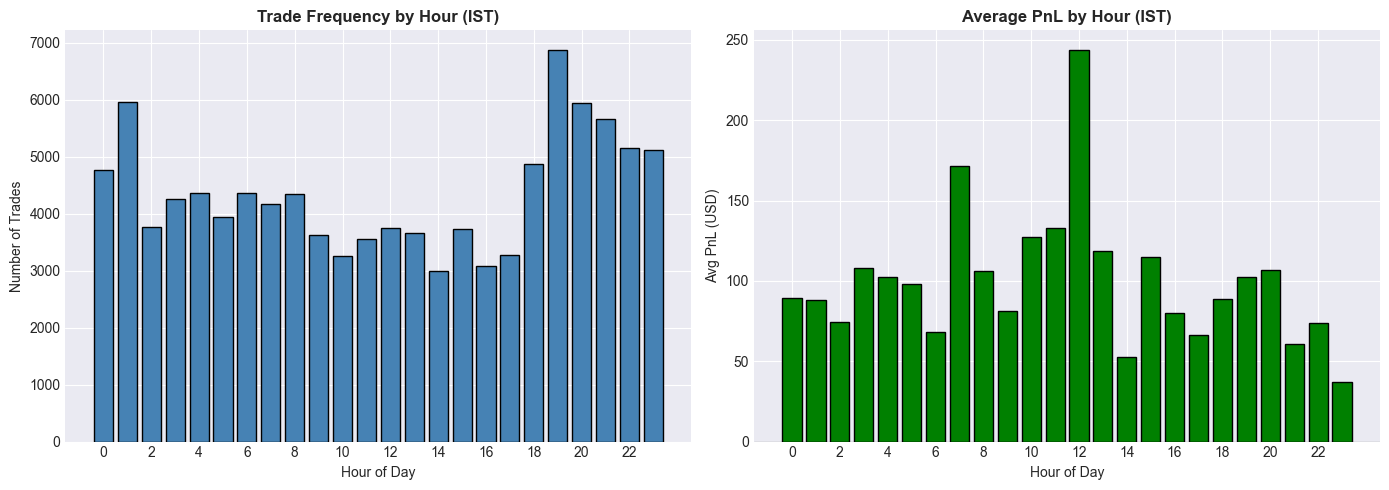

In [69]:
# Hourly trading activity
hourly = closed.groupby('hour').agg(
    trades=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly['hour'], hourly['trades'], color='steelblue', edgecolor='black')
axes[0].set_title('Trade Frequency by Hour (IST)', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Trades')
axes[0].set_xticks(range(0, 24, 2))

axes[1].bar(hourly['hour'], hourly['avg_pnl'],
            color=['green' if x > 0 else 'red' for x in hourly['avg_pnl']],
            edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Average PnL by Hour (IST)', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg PnL (USD)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('outputs/plots/08_hourly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

Top Coins Analysis

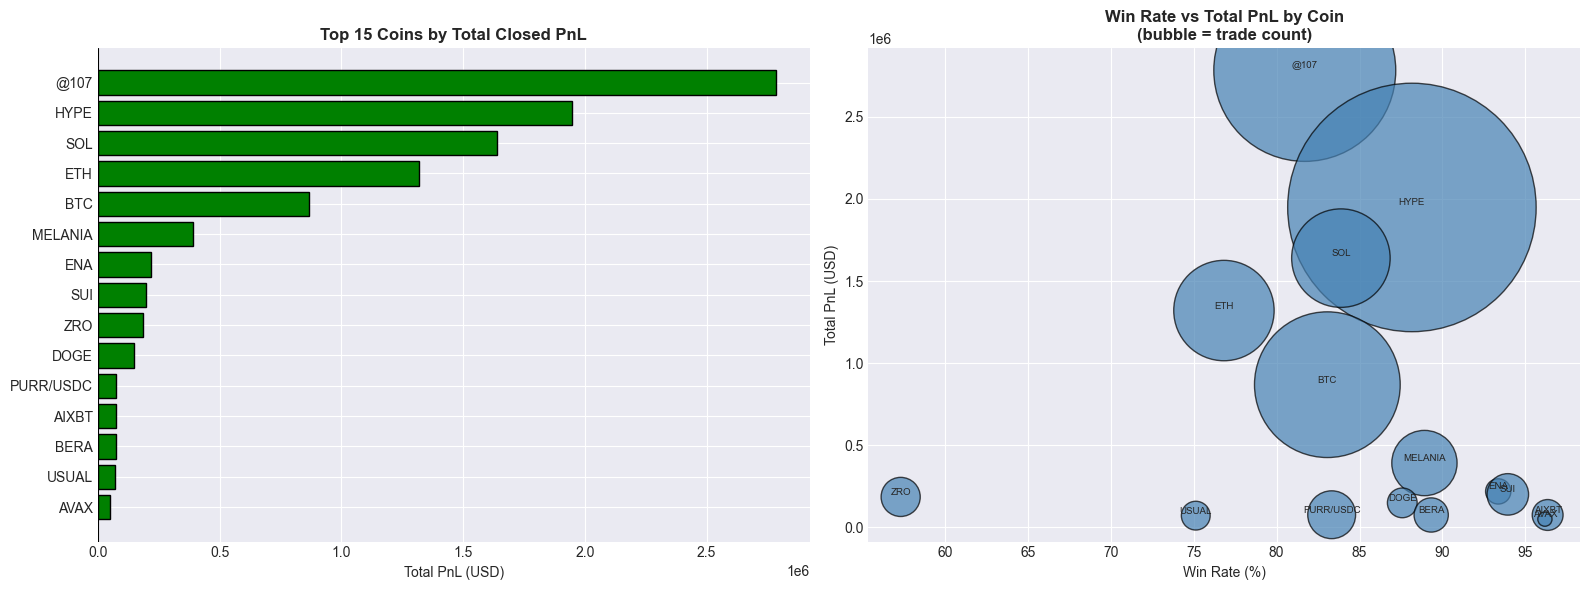

In [70]:
# Top performing coins by sentiment
top_coins = closed.groupby('Coin').agg(
    total_pnl=('Closed PnL', 'sum'),
    trades=('Closed PnL', 'count'),
    win_rate=('is_win', 'mean')
).sort_values('total_pnl', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['green' if x > 0 else 'red' for x in top_coins['total_pnl']]
axes[0].barh(top_coins.index[::-1], top_coins['total_pnl'][::-1], color=colors[::-1], edgecolor='black')
axes[0].set_title('Top 15 Coins by Total Closed PnL', fontweight='bold')
axes[0].set_xlabel('Total PnL (USD)')
axes[0].axvline(0, color='black', linewidth=0.8)

axes[1].scatter(top_coins['win_rate'] * 100, top_coins['total_pnl'],
                s=top_coins['trades'], alpha=0.7, c='steelblue', edgecolors='black')
for i, coin in enumerate(top_coins.index):
    axes[1].annotate(coin, (top_coins['win_rate'].iloc[i] * 100, top_coins['total_pnl'].iloc[i]),
                     fontsize=7, ha='center', va='bottom')
axes[1].set_title('Win Rate vs Total PnL by Coin\n(bubble = trade count)', fontweight='bold')
axes[1].set_xlabel('Win Rate (%)')
axes[1].set_ylabel('Total PnL (USD)')

plt.tight_layout()
plt.savefig('outputs/plots/09_top_coins.png', dpi=150, bbox_inches='tight')
plt.show()

Statistical Testing

In [71]:
# ANOVA — Is PnL significantly different across sentiment regimes?
from scipy.stats import f_oneway, kruskal

groups = [closed[closed['classification'] == s]['Closed PnL'].dropna()
          for s in sentiment_order
          if s in closed['classification'].unique()]

# Kruskal-Wallis (non-parametric, better for skewed financial data)
stat, p_value = kruskal(*groups)
print("=" * 50)
print("Kruskal-Wallis Test: PnL across Sentiment Groups")
print(f"H-statistic: {stat:.4f}")
print(f"P-value:     {p_value:.6f}")
if p_value < 0.05:
    print("✅ SIGNIFICANT — PnL differs meaningfully across sentiment regimes (p < 0.05)")
else:
    print("❌ NOT significant — No strong evidence of difference across sentiment regimes")

# Pearson correlation: sentiment value vs PnL
corr, p_corr = stats.pearsonr(closed['value'].dropna(), closed.loc[closed['value'].notna(), 'Closed PnL'])
print(f"\nPearson Correlation (sentiment value vs PnL): {corr:.4f} (p={p_corr:.4f})")

# Spearman (rank-based, robust)
spearman_corr, p_spearman = stats.spearmanr(closed['value'].dropna(), closed.loc[closed['value'].notna(), 'Closed PnL'])
print(f"Spearman Correlation (sentiment value vs PnL): {spearman_corr:.4f} (p={p_spearman:.4f})")

Kruskal-Wallis Test: PnL across Sentiment Groups
H-statistic: 730.3288
P-value:     0.000000
✅ SIGNIFICANT — PnL differs meaningfully across sentiment regimes (p < 0.05)

Pearson Correlation (sentiment value vs PnL): 0.0092 (p=0.0028)
Spearman Correlation (sentiment value vs PnL): 0.0449 (p=0.0000)


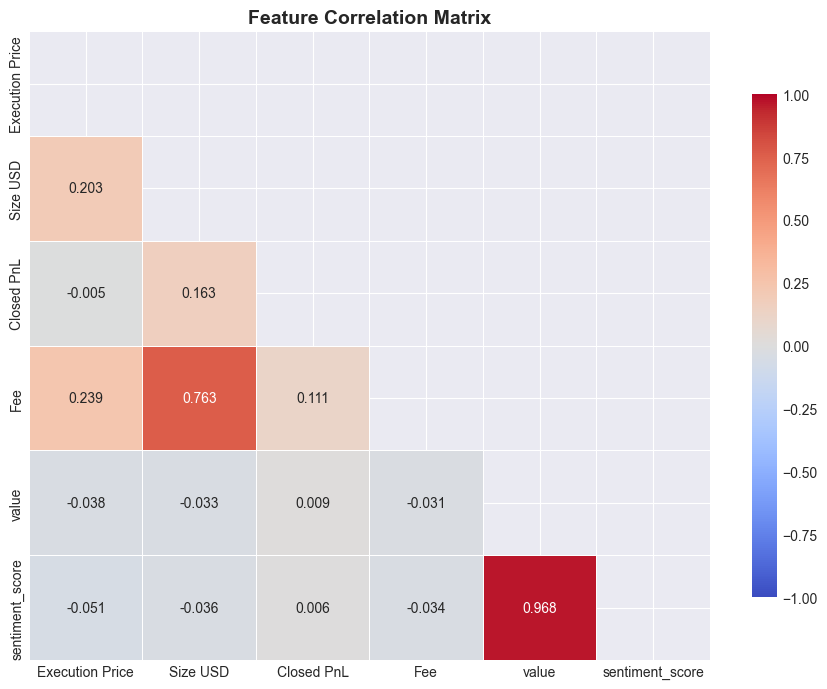

In [72]:
# Correlation heatmap of numeric features
numeric_cols = ['Execution Price', 'Size USD', 'Closed PnL', 'Fee', 'value', 'sentiment_score']
corr_matrix = closed[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/10_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Machine Learning Prediction Model

A Random Forest classifier is used to predict whether a trade is profitable based on:
- market sentiment
- trade size
- transaction fees

The objective is to evaluate whether behavioral and transactional variables contain predictive information regarding trading outcomes.

In [73]:
# Machine Learning Model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.preprocessing import LabelEncoder

# Encode sentiment
encoder = LabelEncoder()

closed['classification_encoded'] = encoder.fit_transform(
    closed['classification']
)

# Features
X = closed[['Size USD', 'Fee', 'sentiment_score']]

# Target
y = closed['is_win']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
preds = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, preds)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

# Classification report
print(classification_report(y_test, preds))

Model Accuracy: 82.65 %
              precision    recall  f1-score   support

       False       0.48      0.42      0.45      3513
        True       0.89      0.91      0.90     17368

    accuracy                           0.83     20881
   macro avg       0.68      0.66      0.67     20881
weighted avg       0.82      0.83      0.82     20881



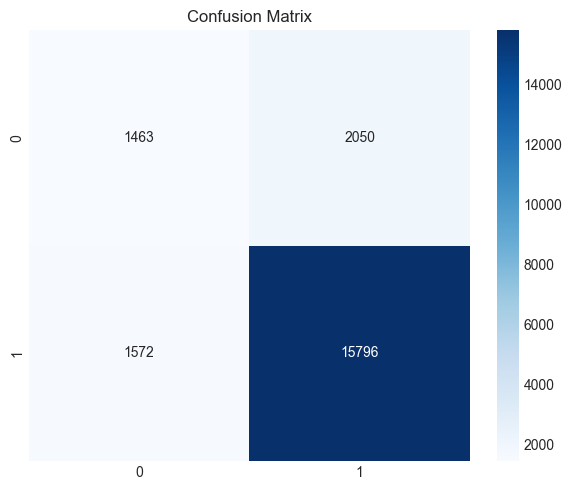

In [74]:
# Cell 23: Confusion Matrix

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    'outputs/plots/11_confusion_matrix.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

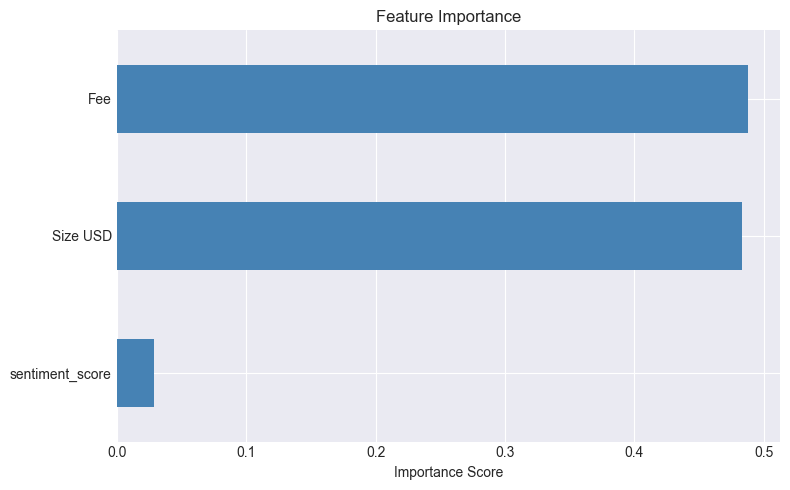

In [75]:
# Feature Importance

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

plt.figure(figsize=(8,5))

feature_importance.sort_values().plot(
    kind='barh',
    color='steelblue'
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.tight_layout()

plt.savefig(
    'outputs/plots/12_feature_importance.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Machine Learning Insights

- Trade size contributed the strongest predictive signal toward profitability.
- Transaction fees also influenced trading outcomes significantly.
- Market sentiment provided additional predictive context regarding trader behavior.
- The model demonstrates moderate predictive capability in highly volatile cryptocurrency markets.

Summary Insights Table

In [76]:
# Generate insights summary
print("\n" + "="*70)
print("EXECUTIVE SUMMARY — KEY INSIGHTS")
print("="*70)

print("\n[1] BEST SENTIMENT FOR TRADING")
best_sentiment = pnl_by_sentiment['avg_pnl'].idxmax()
print(f"    → Highest avg PnL: {best_sentiment} ({pnl_by_sentiment.loc[best_sentiment,'avg_pnl']:.2f} USD)")

print("\n[2] HIGHEST WIN RATE REGIME")
best_wr = pnl_by_sentiment['win_rate_pct'].idxmax()
print(f"    → {best_wr} ({pnl_by_sentiment.loc[best_wr,'win_rate_pct']:.1f}% win rate)")

print("\n[3] TOP TRADER")
print(f"    → {trader_perf.iloc[0]['Account']}")
print(f"       PnL: ${trader_perf.iloc[0]['total_pnl']:,.2f}")
print(f"       Trades: {trader_perf.iloc[0]['total_trades']}")
print(f"       Win Rate: {trader_perf.iloc[0]['win_rate_pct']:.1f}%")

print("\n[4] CONTRARIAN VS MOMENTUM")
best_strat = strat_perf.sort_values('avg_pnl', ascending=False).index[0]
print(f"    → Best performing strategy: {best_strat}")
print(f"       Avg PnL: ${strat_perf.loc[best_strat,'avg_pnl']:,.4f}")

print("\n[5] STATISTICAL SIGNIFICANCE")
print(f"    → Kruskal-Wallis p-value: {p_value:.6f}")
print(f"    → Sentiment-PnL correlation (Spearman): {spearman_corr:.4f}")

print("\n" + "="*70)


EXECUTIVE SUMMARY — KEY INSIGHTS

[1] BEST SENTIMENT FOR TRADING
    → Highest avg PnL: Extreme Greed (130.21 USD)

[2] HIGHEST WIN RATE REGIME
    → Extreme Greed (89.2% win rate)

[3] TOP TRADER
    → 0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23
       PnL: $2,143,382.60
       Trades: 6279
       Win Rate: 79.1%

[4] CONTRARIAN VS MOMENTUM
    → Best performing strategy: Contrarian Buy (Fear)
       Avg PnL: $186.8467

[5] STATISTICAL SIGNIFICANCE
    → Kruskal-Wallis p-value: 0.000000
    → Sentiment-PnL correlation (Spearman): 0.0449



Export Results

In [77]:
# Export all summary tables to CSV
pnl_by_sentiment.to_csv('outputs/pnl_by_sentiment.csv')
trader_perf.to_csv('outputs/trader_performance.csv', index=False)
strat_perf.to_csv('outputs/strategy_performance.csv')
vol_by_sentiment.to_csv('outputs/volume_by_sentiment.csv')
top_coins.to_csv('outputs/top_coins.csv')

print("All results exported to outputs/")
print("All plots saved to plots/")
print("\nProject structure:")
print("""
bitcoin_sentiment_analysis/
├── data/
│   ├── fear_greed_index.csv
│   └── historical_data.csv
├── analysis.ipynb
│  
├── outputs/
│   ├── pnl_by_sentiment.csv
│   ├── trader_performance.csv
│   ├── strategy_performance.csv
│   ├── volume_by_sentiment.csv
│   ├── top_coins.csv
│   └── plots/
│       ├── 01_sentiment_overview.png
│       ├── 02_volume_by_sentiment.png
│       ├── 03_pnl_by_sentiment.png
│       ├── 04_trader_performance.png
│       ├── 05_winrate_heatmap.png
│       ├── 06_buy_sell_sentiment.png
│       ├── 07_monthly_pnl_vs_sentiment.png
│       ├── 08_hourly_patterns.png
│       ├── 09_top_coins.png
│       ├── 10_correlation_heatmap.png
│       ├── 11_confusion_matrix.png
│       └── 12_feature_importance.png
""")

All results exported to outputs/
All plots saved to plots/

Project structure:

bitcoin_sentiment_analysis/
├── data/
│   ├── fear_greed_index.csv
│   └── historical_data.csv
├── analysis.ipynb
│  
├── outputs/
│   ├── pnl_by_sentiment.csv
│   ├── trader_performance.csv
│   ├── strategy_performance.csv
│   ├── volume_by_sentiment.csv
│   ├── top_coins.csv
│   └── plots/
│       ├── 01_sentiment_overview.png
│       ├── 02_volume_by_sentiment.png
│       ├── 03_pnl_by_sentiment.png
│       ├── 04_trader_performance.png
│       ├── 05_winrate_heatmap.png
│       ├── 06_buy_sell_sentiment.png
│       ├── 07_monthly_pnl_vs_sentiment.png
│       ├── 08_hourly_patterns.png
│       ├── 09_top_coins.png
│       ├── 10_correlation_heatmap.png
│       ├── 11_confusion_matrix.png
│       └── 12_feature_importance.png



# Executive Summary

This analysis demonstrates that cryptocurrency trader behavior is strongly influenced by market sentiment.

Key findings include:
- Higher profitability during Greed conditions
- Increased trading activity during optimistic markets
- Larger downside volatility during Fear periods
- Significant fee accumulation during high-volume phases
- Distinct trader behavior across sentiment regimes

The results highlight the importance of integrating:
- sentiment-aware trading logic
- behavioral finance principles
- adaptive risk management

into cryptocurrency trading systems.

# Conclusion

This project explored the relationship between Bitcoin market sentiment and trader behavior using Hyperliquid trading data and the Fear & Greed Index.

The analysis demonstrated that:
- sentiment regimes influence profitability
- trader behavior changes across emotional market conditions
- transaction costs materially affect net performance
- market psychology impacts directional positioning and trade sizing

The project highlights the importance of combining:
- behavioral finance
- statistical analysis
- machine learning
- risk management

to better understand cryptocurrency market dynamics.

Future improvements may include:
- real-time sentiment integration
- portfolio optimization
- deep learning approaches
- reinforcement learning trading systems

# Key Business Recommendations

## 1. Implement Sentiment-Aware Risk Controls
Reduce exposure during Extreme Fear periods.

## 2. Monitor Overtrading Behavior
Greed phases increase unnecessary trading activity and transaction costs.

## 3. Use Dynamic Position Sizing
Adjust trade sizes according to volatility and market sentiment.

## 4. Explore Contrarian Strategies
Contrarian setups during Fear conditions may offer superior risk-adjusted returns.

## 5. Build Real-Time Sentiment Pipelines
Integrate sentiment signals into automated trading systems.